# Regression - Model training and Evaluation

- Dependent variable (y) - predict
- Independent variable (x) - used to predict y

simple linear regression: 
* y = mx+c 
* y = m1x1 + m2x2 + m3x3 + c
* y = m.x.^3 + m2x2^2 + m3x3 + c

Evaluation ways
* MAE - mean abosolute error AVG(y-ypred)
* MSE - Mean squared error (AVG(y-ypred)^2)
* R2 score

#### Finding of R2 score
- R2 = 1- (SSres/Sum of square of total)

In [4]:
import pandas as pd
import numpy as np 

df = pd.read_csv('Book2.csv')
df.head(2)



,x,y
0,15,49
1,23,63


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   x       15 non-null     int64
 1   y       15 non-null     int64
dtypes: int64(2)
memory usage: 372.0 bytes


In [5]:
df.isna().sum()

x    0
y    0
dtype: int64

In [6]:
print(type(df['x']))
print(type(df['y']))



<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


##### we need x as df and y as series so chaigning them and let's do it

In [9]:
x = df.iloc[:,0:1] # second slicing operator for the type change
y = df.iloc[:,-1] 

print(type(x))
print(type(y))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [12]:
# doing it without test the csv way
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x,y)
y_pred = lr.predict(x)
print(y_pred)


[47.45652174 62.60810811 53.13836663 62.60810811 64.5020564  60.71415981
 60.71415981 55.03231492 55.03231492 49.35047004 64.5020564  39.88072855
 64.5020564  49.35047004 62.60810811]


In [13]:
# difference 
diff = pd.DataFrame({'Actual': y, 'Predict': y_pred})
diff.head()

,Actual,Predict
0,49,47.456522
1,63,62.608108
2,58,53.138367
3,60,62.608108
4,58,64.502056


In [14]:
# errors
print('Coefficent ', lr.coef_)
print('Intercept: ',lr.intercept_)


Coefficent  [1.8939483]
Intercept:  19.04729729729729


In [15]:
# erros 2
from sklearn import metrics
print(f'MAR: {metrics.mean_absolute_error(y,y_pred)}')
print(f'MAS: {metrics.mean_squared_error(y,y_pred)}')
print(f'R2 Score: {metrics.r2_score(y,y_pred)}')

MAR: 3.7412847630238937
MAS: 22.292068155111632
R2 Score: 0.7088287858527739


In [ ]:
# 

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1, random_state=1)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(13, 1)
(2, 1)
(13,)
(2,)


In [20]:
lr = LinearRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)
print(y_pred)


[62.41322902 54.56827881]


In [26]:
# difference 
diff = pd.DataFrame({'Actual': y_test, 'Predict': y_pred})
diff.head()

,Actual,Predict
3,60,62.413229
7,63,54.568279


In [27]:
# errors
print('Coefficent ', lr.coef_)
print('Intercept: ',lr.intercept_)


Coefficent  [1.96123755]
Intercept:  17.30476529160738


In [29]:
# erros 2
from sklearn import metrics
print(f'MAE: {metrics.mean_absolute_error(y_test,y_pred)}')
print(f'MAS: {metrics.mean_squared_error(y_test,y_pred)}')
print(f'R2 Score: {metrics.r2_score(y_test,y_pred)}')

MAE: 5.422475106685635
MAS: 38.458798301932994
R2 Score: -16.092799245303553


#### example

In [1]:
import pandas as pd 
import numpy as np 

df = pd.DataFrame({'Hours Studied': [1,2,3,4,5,6,7], 
                    'Exam Score': [50,55,65,70,75,80,85]})
df

,Hours Studied,Exam Score
0,1,50
1,2,55
2,3,65
3,4,70
4,5,75
5,6,80
6,7,85


## Process
1. DataFrame
2. info(),isna() for cleaning
3. define x,y
4. Train test (if needed)
5. Regression mode
6. Predicition
7. DataFrame(y/ytest, y_pred)
8. coef_,intercept
9. MAE,MSE,R2 score

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Hours Studied  7 non-null      int64
 1   Exam Score     7 non-null      int64
dtypes: int64(2)
memory usage: 244.0 bytes


In [5]:
df.isna().sum()

Hours Studied    0
Exam Score       0
dtype: int64

#### can use df[['name']] for df and df['name'] for series

In [8]:
x= df.iloc[:,0:1]
y = df.iloc[:,-1]

In [9]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x,y)

y_pred = lr.predict(x)
print(y_pred)

[50.89285714 56.78571429 62.67857143 68.57142857 74.46428571 80.35714286
 86.25      ]


In [11]:
diff = pd.DataFrame({'Actual': y, 'Predict': y_pred})
diff.head()

,Actual,Predict
0,50,50.892857
1,55,56.785714
2,65,62.678571
3,70,68.571429
4,75,74.464286


In [12]:
print('Coeffiecent',lr.coef_)
print('Intercept',lr.intercept_)

Coeffiecent [5.89285714]
Intercept 45.0


In [13]:
# Metrics
from sklearn import metrics as m 

print(f'MAE: {m.mean_absolute_error(y,y_pred)}')
print(f'MAS: {m.mean_squared_error(y,y_pred)}')
print(f'R2 Score: {m.r2_score(y,y_pred)}')

MAE: 1.2244897959183672
MAS: 1.9132653061224514
R2 Score: 0.9864130434782609


## Graphical Representation of a REgression Model

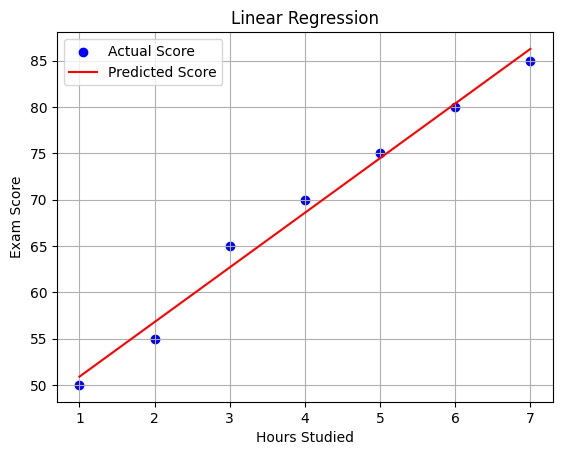

In [17]:
from sqlalchemy import label
import matplotlib.pyplot as plt 
plt.scatter(x,y,color='blue',label='Actual Score')
plt.plot(x,y_pred,color='red',label='Predicted Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression')
plt.legend()
plt.grid(True)
plt.show()

### example

In [18]:
df = pd.read_csv('Book1.csv')
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cgpa     200 non-null    float64
 1   package  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [20]:
df.isna().sum()

cgpa       0
package    0
dtype: int64

In [21]:
x = df[['cgpa']]
y = df['package']


In [47]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=19,test_size=0.3)
print(x_train.shape)
print(y_train.shape)

(140, 1)
(140,)


In [48]:
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)
y_pred

array([4.38187377, 3.5439274 , 2.65467819, 2.58057409, 2.98529648,
       2.35826179, 3.35011667, 3.18480753, 2.39246368, 4.12535957,
       3.65223339, 2.79148576, 2.93399365, 2.56347314, 2.39816399,
       4.34197156, 3.4698233 , 2.83138797, 3.23611036, 2.72308197,
       3.09360248, 2.23285485, 2.64897787, 3.01379806, 2.56347314,
       2.96249522, 3.34441636, 1.64002204, 2.3639621 , 2.62617661,
       1.95353939, 2.15875074, 3.21900942, 3.23041005, 3.77194002,
       3.73773812, 2.50646999, 3.2133091 , 3.23041005, 2.26135642,
       3.07080122, 2.88269081, 3.84604412, 3.93724916, 2.97959617,
       3.139205  , 3.44132172, 3.18480753, 3.49262456, 3.46412298,
       2.98529648, 2.88839112, 3.19050784, 2.38676336, 3.18480753,
       2.55207251, 2.01624286, 3.19620816, 3.08790216, 3.53822708])

In [49]:
diff = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
diff.head()

,Actual,Predicted
40,4.02,4.381874
140,3.15,3.543927
33,2.73,2.654678
91,2.14,2.580574
13,2.89,2.985296


In [50]:
print('Coreffiecnt',lr.coef_)
print('Intercept',lr.intercept_)

Coreffiecnt [0.57003154]
Intercept -0.9650221207944085


In [51]:
print(f'MAE: {m.mean_absolute_error(y_test,y_pred)}')
print(f'MAS: {m.mean_squared_error(y_test,y_pred)}')
print(f'R2 Score: {m.r2_score(y_test,y_pred)}')

MAE: 0.21067086672666643
MAS: 0.07398322282163168
R2 Score: 0.8104816443521474


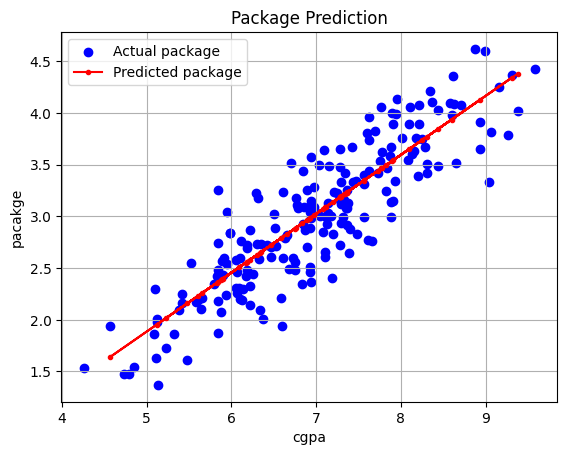

In [53]:

plt.scatter(x,y,color='blue',label='Actual package')
plt.plot(x_test,y_pred,color='red',label='Predicted package',marker='.')
plt.legend()
plt.xlabel('cgpa')
plt.ylabel('pacakge')
plt.title('Package Prediction')
plt.grid(True)
plt.show()

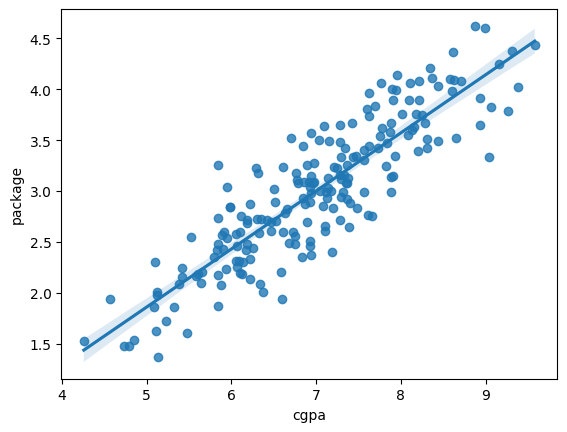

In [54]:
## REgression plot
import seaborn as sns 
sns.regplot(df,x='cgpa',y='package')
plt.show()

## Predict using user input

In [63]:
n = float(input('Enter ur cgpa: '))
y_pred = lr.predict([[n]])
print('Your package will be: ',y_pred)

Your package will be:  [4.73529333]


c:\Users\Dhruvil\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Multiple Linear Regression

In [101]:
df = pd.read_csv("car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [102]:
df.drop(columns=['Car_Name'],inplace=True)

In [103]:
# one hot encoding
df = pd.get_dummies(df, columns=['Fuel_Type','Seller_Type','Transmission'], drop_first=True, dtype=int)
df

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,0,1,0,1
1,2013,4.75,9.54,43000,0,1,0,0,1
2,2017,7.25,9.85,6900,0,0,1,0,1
3,2011,2.85,4.15,5200,0,0,1,0,1
4,2014,4.60,6.87,42450,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,0,1,0,0,1
297,2015,4.00,5.90,60000,0,0,1,0,1
298,2009,3.35,11.00,87934,0,0,1,0,1
299,2017,11.50,12.50,9000,0,1,0,0,1


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Year                    301 non-null    int64  
 1   Selling_Price           301 non-null    float64
 2   Present_Price           301 non-null    float64
 3   Kms_Driven              301 non-null    int64  
 4   Owner                   301 non-null    int64  
 5   Fuel_Type_Diesel        301 non-null    int64  
 6   Fuel_Type_Petrol        301 non-null    int64  
 7   Seller_Type_Individual  301 non-null    int64  
 8   Transmission_Manual     301 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 21.3 KB


In [105]:
df.isna().sum()

Year                      0
Selling_Price             0
Present_Price             0
Kms_Driven                0
Owner                     0
Fuel_Type_Diesel          0
Fuel_Type_Petrol          0
Seller_Type_Individual    0
Transmission_Manual       0
dtype: int64

In [106]:
# Feature Transformation
df['age'] = 2026 -df['Year']
df.drop(columns=['Year'],inplace=True)
df.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,age
0,3.35,5.59,27000,0,0,1,0,1,12
1,4.75,9.54,43000,0,1,0,0,1,13
2,7.25,9.85,6900,0,0,1,0,1,9
3,2.85,4.15,5200,0,0,1,0,1,15
4,4.60,6.87,42450,0,1,0,0,1,12


In [ ]:
x = df[['age','Present_Price','Kms_Driven','Fuel_Type_Diesel','Fuel_Type_Petrol','Seller_Type_Individual','Transmission_Manual','Owner']]
# or x = df.drop('Selling_Price',axis=1)
y = df['Selling_Price']

In [108]:
from sklearn import metrics
m = {}
for  i in range(43):
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3, random_state=i)
    lr = LinearRegression()
    lr.fit(x_train,y_train)
    y_pred = lr.predict(x_test)
    m[i]= metrics.mean_absolute_error(y_test,y_pred)
 
minimum = min(m.values())
k = [i for i,j in m.items() if j ==minimum]
print(k,minimum)

[32] 0.9588249796694437


In [109]:

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=32)


In [110]:
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)
y_pred

array([10.19255971,  9.35631621,  3.01923493,  7.73443664,  8.89251294,
        4.78729653,  1.38188934,  0.08422832,  1.62446584,  0.2437856 ,
        4.18870157,  8.27852806, -0.13452935,  0.18654154,  3.81766594,
        4.37557428,  0.08644962,  5.7176069 ,  0.7715219 ,  3.01047622,
        8.21590529, 10.1412951 ,  2.54967856,  1.63961815,  2.87244018,
        6.51098017,  3.44386035, -2.85737966,  3.62473707,  4.42871424,
        0.383235  ,  2.06506047,  1.29065946,  4.07837733,  4.358138  ,
        0.29589407,  1.75614859, -1.18046914,  8.19355937,  7.68889042,
        3.68919628,  4.96471715,  7.69215708,  7.52808932,  3.85275305,
        2.45711394, -2.71891239,  8.91136421,  1.29013475,  6.29376217,
        1.41448972,  2.09816562,  5.29533466,  1.08620839,  6.07469913,
        5.10591871,  1.17542182, 14.22666329,  6.18967869,  8.24882401,
        8.13659703,  1.61499152,  9.76501068,  2.35331496, -1.13464281,
        1.92887624,  8.91136421,  5.3515923 ,  5.22377979,  1.92

In [111]:
diff = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
diff.head()

,Actual,Predicted
91,11.25,10.192560
295,8.55,9.356316
19,2.65,3.019235
276,8.65,7.734437
60,6.95,8.892513


In [112]:
print('Coreffiecnt',lr.coef_)
print('Intercept',lr.intercept_)

Coreffiecnt [-4.48582746e-01  4.25248904e-01 -4.95067539e-06  2.38679649e+00
  3.73399960e-01 -1.18833729e+00 -1.46561481e+00 -7.93010571e-01]
Intercept 8.100453357023664


In [113]:
print(f'MAE: {metrics.mean_absolute_error(y_test,y_pred)}')
print(f'MAS: {metrics.mean_squared_error(y_test,y_pred)}')
print(f'R2 Score: {metrics.r2_score(y_test,y_pred)}')

MAE: 0.9588249796694437
MAS: 1.648760818163443
R2 Score: 0.8696877471915905


In [116]:
year = int(input('Enter the manufacture year of the car: '))
age = 2026 - year
price = float(input('Enter Present Price'))
km = float(input('Enter Km dirven without km'))
fuel_type = input('Enter Fuel type (Diesel,petrol,Cng): ').lower()
if fuel_type == 'cng':
    f_p,f_d = 0,0
elif fuel_type == 'petrol':
    f_p,f_d = 1,0
elif fuel_type == 'diesel':
    f_p,f_d = 0,1
else: 
    print('Enter a valid choice')

trans_type = input('Enter Transmission type (manual auto): ').lower()
if trans_type == 'manual':
    t_m = 1
elif trans_type == 'auto':
    t_m = 0
s_type = input('Enter Transmission type (dealer, indv): ').lower()

if s_type == 'dealer':
    s_i = 0
elif s_type == 'indv':
    s_i = 1
owner = int(input('Enter Number of past owners: '))

x = [age,price,km,f_d,f_p,s_i,t_m,owner]
y_pred = lr.predict([x])
print('Selling Price of your car: ',y_pred)

Selling Price of your car:  [10.26768191]


c:\Users\Dhruvil\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
sns.regplot(df,x=['age','Present_Price','Kms_Driven','Fuel_Type_Diesel','Fuel_Type_Petrol','Seller_Type_Individual','Transmission_Manual','Owner'],y='Selling_Price')